In [1]:
import time

import cooler
from cooler.util import open_hdf5
import cooltools
import matplotlib.pyplot as plt
from numpy import log2, nan
import pandas
import seaborn as sns

import hicona

In [2]:
FILE_PATH = "test_files/small.mcool::resolutions/10000"
TEST_CHROM = "chr1"

In [3]:
c = hicona.HiconaCooler(FILE_PATH)

In [4]:
lower, upper = c.extent(TEST_CHROM)
with open_hdf5(c.store, mode="r") as h5_handle:
    h5_grp = h5_handle[c.root]
    lo_pix = h5_grp["indexes/bin1_offset"][lower]
    hi_pix = h5_grp["indexes/bin1_offset"][upper]
    
chrom = pandas.DataFrame(
    data = [[TEST_CHROM, 0, c.chromsizes[TEST_CHROM], TEST_CHROM]], 
    columns=["chrom", "start", "end", "name"]
)
chrom

,chrom,start,end,name
0,chr1,0,248956422,chr1


In [5]:
start_cooltools = time.time()
cvd = cooltools.expected_cis(
    clr=c, 
    view_df= chrom,
    smooth=False, 
    aggregate_smoothed=False, 
    nproc=1
)
cooltools_time = time.time() - start_cooltools

In [6]:
cvd

,region1,region2,dist,n_valid,count.sum,balanced.sum,count.avg,balanced.avg
0,chr1,chr1,0,21915,NaN,NaN,NaN,NaN
1,chr1,chr1,1,21757,NaN,NaN,NaN,NaN
2,chr1,chr1,2,21721,357732.0,202.948484,16.469407,0.009343
3,chr1,chr1,3,21703,271741.0,154.254057,12.520896,0.007107
4,chr1,chr1,4,21682,223202.0,126.710732,10.294346,0.005844
...,...,...,...,...,...,...,...,...
24891,chr1,chr1,24891,0,0.0,0.000000,NaN,NaN
24892,chr1,chr1,24892,0,0.0,0.000000,NaN,NaN
24893,chr1,chr1,24893,0,0.0,0.000000,NaN,NaN
24894,chr1,chr1,24894,0,0.0,0.000000,NaN,NaN


In [7]:
cooltools_time

247.7227382659912

In [23]:
start_hicona = time.time()
stat = "median"
pix_df = c.pixels()[lo_pix:hi_pix]
pix_df["bin_difference"] = pix_df["bin2_id"] - pix_df["bin1_id"]
indexer = pix_df[pix_df["bin2_id"] >= upper].index
pix_df.drop(indexer, inplace=True)
group_counts = pix_df.groupby("bin_difference")["count"]
decay_curve = group_counts.agg(stat).to_frame()
hicona_time = time.time() - start_hicona

In [9]:
hicona_time

11.05448842048645

In [10]:
decay_curve

,count
bin_difference,
0,115.0
1,26.0
2,15.0
3,11.0
4,9.0
...,...
24812,1.0
24815,1.0
24817,1.0


In [11]:
comparison = cvd.copy()
comparison.drop(
    ["region1", "region2", "dist", "n_valid", "count.sum", "balanced.sum", "balanced.avg"], 
    axis=1, 
    inplace = True
)
comparison = comparison.merge(decay_curve, how="outer", left_index=True, right_index=True)
comparison.rename(columns={"count.avg": "cooltools", "count":"hicona"}, inplace=True)
comparison["hicona"][0] = nan
comparison["hicona"][1] = nan
comparison.reset_index(inplace=True, names=["bin_difference"])
comparison

,bin_difference,cooltools,hicona
0,0,NaN,NaN
1,1,NaN,NaN
2,2,16.469407,15.0
3,3,12.520896,11.0
4,4,10.294346,9.0
...,...,...,...
24891,24891,NaN,NaN
24892,24892,NaN,NaN
24893,24893,NaN,1.0
24894,24894,NaN,NaN


In [12]:
hico_val = sum(comparison["hicona"]>=0)
cool_val = sum(comparison["cooltools"]>=0)

hico_val, cool_val

(24749, 24864)

In [13]:
plot_df = pandas.melt(comparison, id_vars=["bin_difference"], value_vars=["cooltools", "hicona"])
plot_df.rename(columns={"variable":"method", "value":"exp_count"}, inplace=True)
plot_df

,bin_difference,method,exp_count
0,0,cooltools,NaN
1,1,cooltools,NaN
2,2,cooltools,16.469407
3,3,cooltools,12.520896
4,4,cooltools,10.294346
...,...,...,...
49787,24891,hicona,NaN
49788,24892,hicona,NaN
49789,24893,hicona,1.000000
49790,24894,hicona,NaN


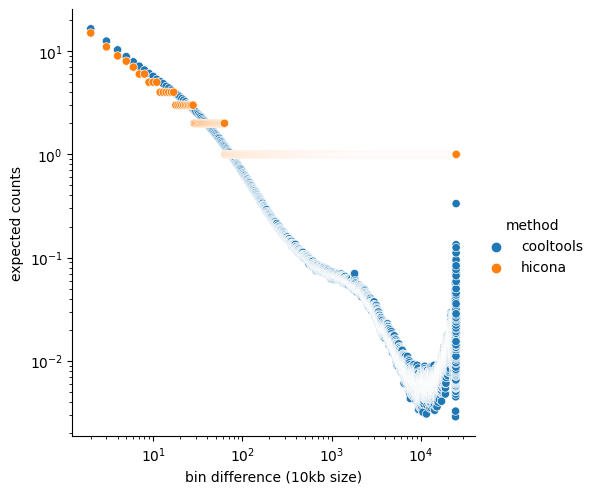

In [14]:
ax = sns.relplot(data=plot_df, x='bin_difference', y='exp_count', hue='method', aspect=1)
ax.set(xlabel='bin difference (10kb size)', ylabel='expected counts')
plt.yscale('log')
plt.xscale('log')
plt.show()

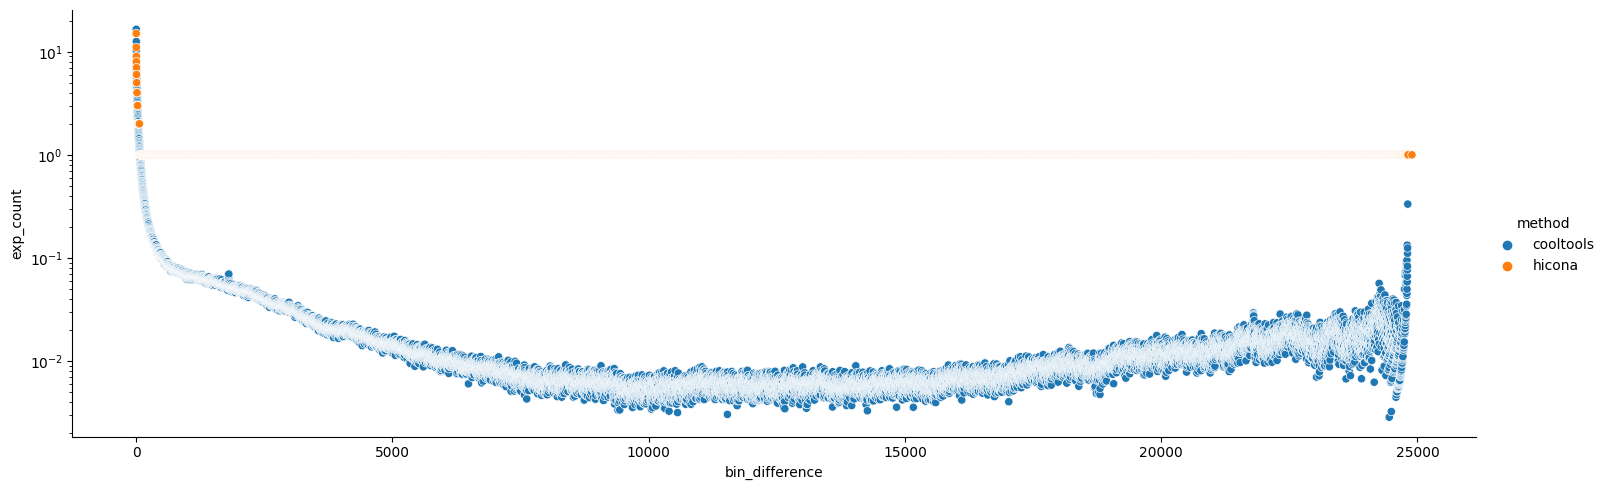

In [15]:
plt.close()
sns.relplot(data=plot_df, x='bin_difference', y='exp_count', hue='method', aspect=3)
plt.xscale('linear')
plt.yscale('log')
plt.show()